# NovaGen Healthcare Risk Prediction

## Project Overview

NovaGen Research Labs is conducting population health studies to identify individuals who may be at higher health risk based on medical and lifestyle indicators. 

The objective of this project is to build a Machine learning Classification system capable of predicting whether an individual is "Healthy" or "Unhealthy" using healthcare-related attributes such as BMT, blood pressure, cholesterol, stress levels, sleep habits, and other physiological indicators.

This project includes : 
- Exploratory Data Analysis (EDA)
- Data Visualization
- Correlation Analysis
- Feature Importance Analysis
- Model Building and Evaluation
- Explainable AI using SHAP
- Streamlit Deployment 

# Import Required Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot visuals
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load Dataset

The dataset contains healthcare and lifestyle-related attributes collected from individuals across observational studies. 

In [6]:
df = pd.read_csv("../data/novagen_dataset.csv")

# Basic Data Exploration

In this section, we examine:
- dataset dimensions
- feature types
- missing values
- sample records

In [10]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [11]:
df.shape

(9549, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [7]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


# Data Cleaning

The dataset is checked for : 
- missing values
- duplicate records
- inconsistencies

In [6]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

No missing values are observed

# Target Variable Distribution

We analyze the balance between healthy and unhealthy individuals to understand potential class imbalance.

In [16]:
df["Target"].value_counts()

Target
1    4979
0    4570
Name: count, dtype: int64

There seems to be a slight imbalance in Target Distribution

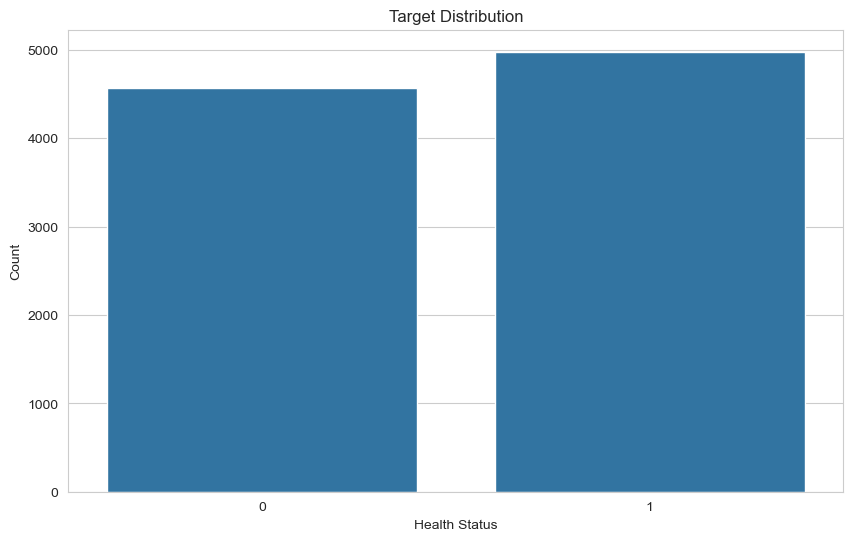

In [9]:
# visualization
sns.countplot(x="Target", data=df)

plt.title("Target Distribution")
plt.xlabel("Health Status")
plt.ylabel("Count")

plt.show()

# Feature Distributions

Distribution plots help identify:
- skewness
- spread
- concentration patterns
- potential outliers

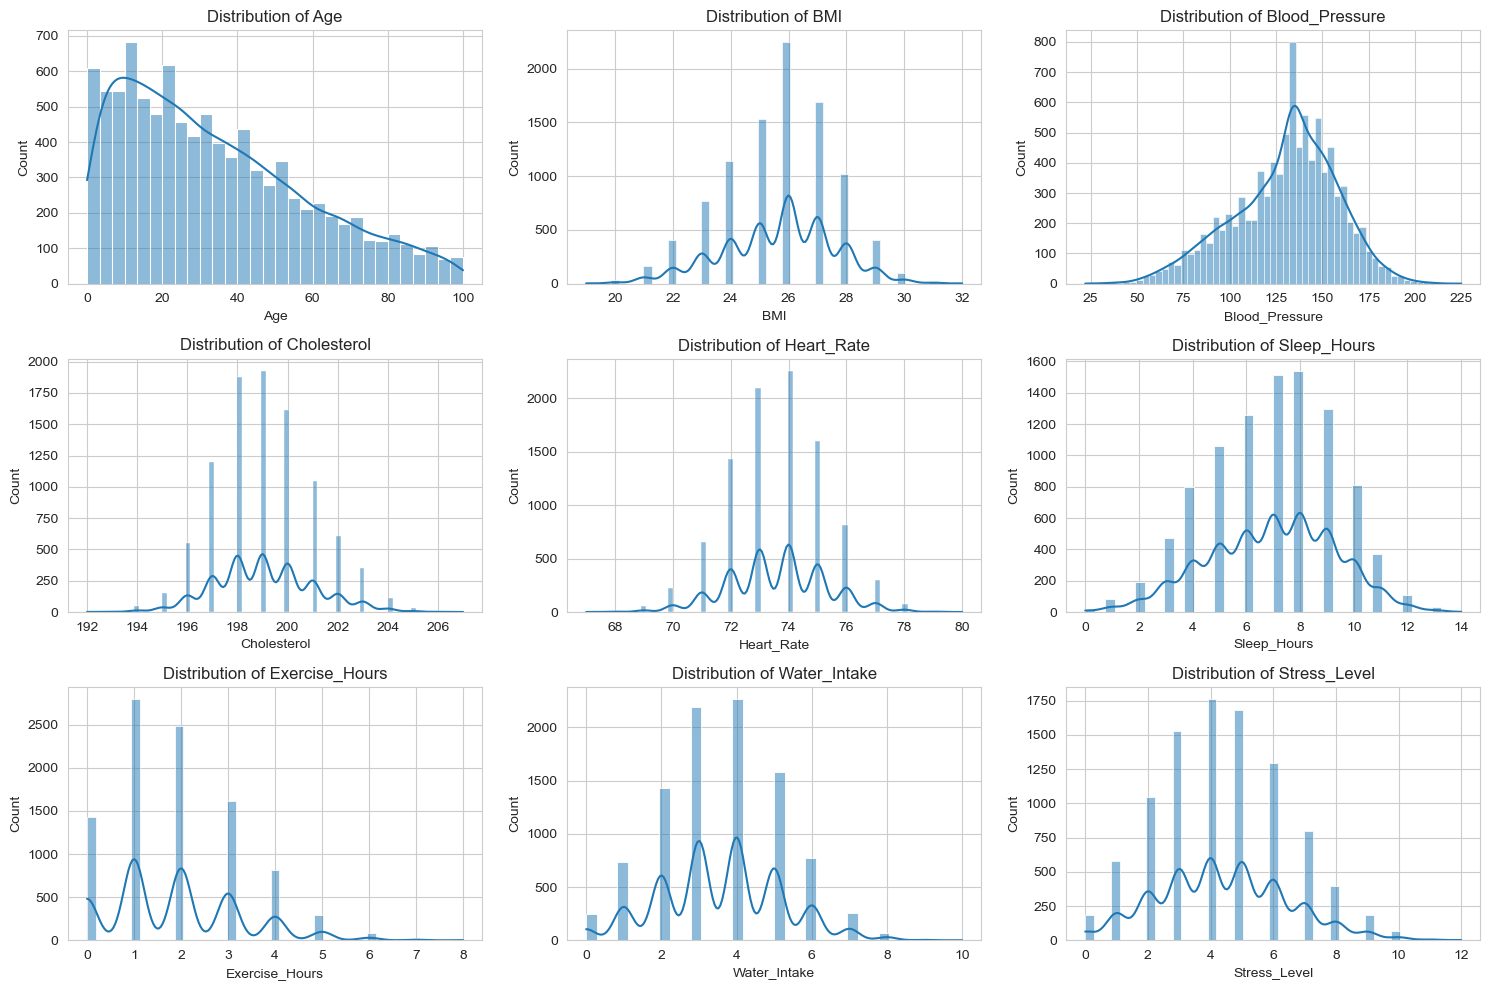

In [17]:
numerical_cols = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Heart_Rate",
    "Sleep_Hours",
    "Exercise_Hours",
    "Water_Intake",
    "Stress_Level"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        kde = True,
        ax = axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Correlation Analysis

Correlation analysis was performed in two stages:
1. Correlation of features with the target variable to identify the most influential health indicators.
2. A full feature correlation heatmap to analyze relationships among numerical variables and detect potential dependencies between features.

In [13]:
correlation_with_target = df.corr()["Target"].sort_values(ascending=False)

print(correlation_with_target)

Target                   1.000000
BMI                      0.413972
Stress_Level             0.119455
Sleep_Hours              0.025931
Diet_Type__Vegan         0.023707
Exercise_Hours           0.008214
Blood_Group_B            0.007749
Diet                     0.005602
Alcohol                  0.003077
Blood_Group_AB           0.001174
MedicalHistory          -0.001666
PhysicalActivity        -0.002511
Blood_Group_O           -0.002728
Allergies               -0.004322
Diet_Type__Vegetarian   -0.005176
Smoking                 -0.005283
MentalHealth            -0.016372
Water_Intake            -0.038406
Heart_Rate              -0.065957
Glucose_Level           -0.072148
Age                     -0.190743
Cholesterol             -0.324361
Blood_Pressure          -0.380279
Name: Target, dtype: float64


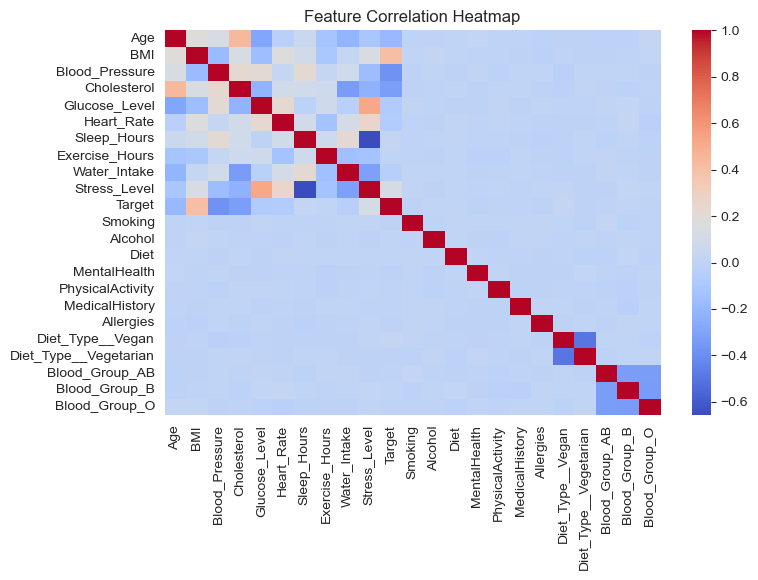

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Key Insights from EDA

## Observations
- During exploratory analysis, several categorical lifestyle-related variables such as Smoking, Alcohol Consumption, Mental Health, Physical Activity, Medical History, and Allergies were observed to contain values beyond the documented binary representation.
- Although the dataset documentation described some variables as binary (0/1), the actual dataset included three ordinal categories (0, 1, 2). These features were therefore treated as ordinal categorical indicators during model training.
- Tree-based ensemble models such as Random Forest and XGBoost are naturally capable of handling such ordinal integer-encoded features effectively.
- The dataset was relatively clean with no significant missing values or duplicate records.
- A slight class imbalance was observed in the target variable, with unhealthy individuals slightly outnumbering healthy individuals.
- BMI emerged as one of the strongest indicators associated with health risk, showing the highest positive correlation with the target variable. 
- Blood Pressure and Cholesterol also demonstrated strong relationships with unhealthy outcomes, suggesting their major influence in risk prediction. 
- Stress Level showed moderate positive association with health risk, indicating the importance of lifestyle and mental well-being factors.
- Features such as Sleep Hours, Water Intake, and Exercise Hours showed weaker but still noticeable influence on overall health condition.
- Distribution plots revealed that most numerical features followed approximately normal or moderately skewed distributions, with no severe outlier issues.
- Correlation analysis indicated that several physiological indicators are interrelated, though extreme multicollinearity was not observed.
